**GLOBAL HUNGER INDEX**

In [ ]:
from google.colab import drive
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/Samsung/ÖdevGrup13/2025.xlsx'

df_drive = pd.read_excel(file_path)
xls = pd.ExcelFile(file_path)
print(xls.sheet_names)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['GHI Ranking 2025', 'GHI Indicator Values 2025', 'GHI Scores 2025 ']


In [ ]:
df = pd.read_excel(file_path, sheet_name="GHI Scores 2025 ")

# ilk satırları gör
df.head()

,"2000, 2008, 2016, AND 2025 GLOBAL HUNGER INDEX SCORES, AND CHANGE SINCE 2016",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Country\n with data from,2000\n'98-'02,2008\n'06-'10,2016\n'14-'18,2025\n'20-'24,Absolute change since 2016,% change since 2016
1,Afghanistan,49.6,32.7,28,29,1,3.4
2,Albania,15.3,15.3,6.7,7,0.3,4.3
3,Algeria,14.1,10.8,8,7.1,-0.9,-12.7
4,Angola,63.8,35.3,25.7,29.7,4,13.5


In [ ]:
# veri bilgisi
df.info()

# eksik değerler
df.isnull().sum()

# temel istatistikler
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 140 entries, 0 to 139
Data columns (total 7 columns):
 #   Column                                                                        Non-Null Count  Dtype 
---  ------                                                                        --------------  ----- 
 0   2000, 2008, 2016, AND 2025 GLOBAL HUNGER INDEX SCORES, AND CHANGE SINCE 2016  139 non-null    object
 1   Unnamed: 1                                                                    137 non-null    object
 2   Unnamed: 2                                                                    137 non-null    object
 3   Unnamed: 3                                                                    137 non-null    object
 4   Unnamed: 4                                                                    137 non-null    object
 5   Unnamed: 5                                                                    137 non-null    object
 6   Unnamed: 6                                 

,"2000, 2008, 2016, AND 2025 GLOBAL HUNGER INDEX SCORES, AND CHANGE SINCE 2016",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
count,139,137,137,137,137,137,137
unique,139,102,100,88,87,82,94
top,Country\n with data from,—,<5,<5,<5,—,—
freq,1,15,12,18,25,39,39


DataFrame sütunları: Index(['Country\n                        with data from', '2000\n'98-'02',
       '2008\n'06-'10', '2016\n'14-'18', '2025\n'20-'24',
       'Absolute change since 2016', '% change since 2016'],
      dtype='object')


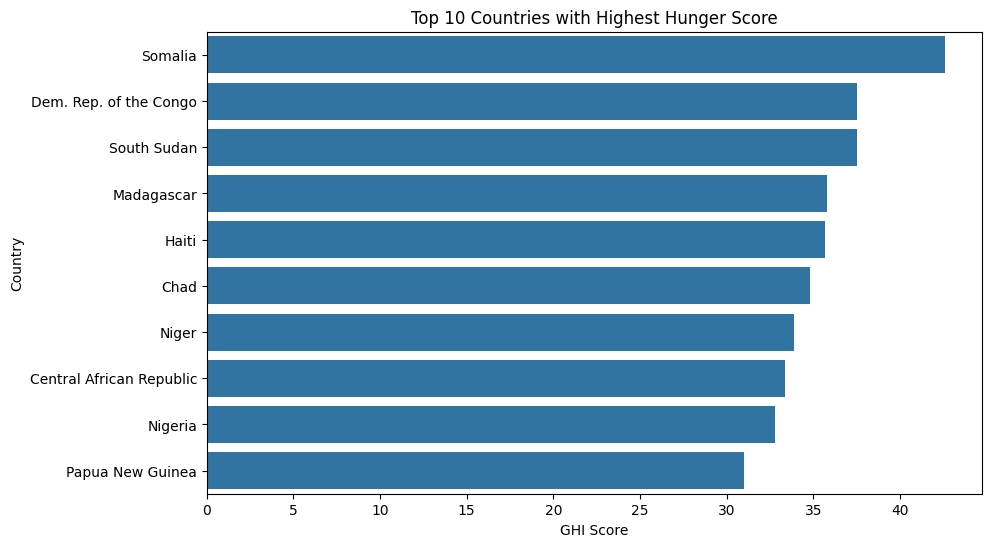

In [ ]:
df = pd.read_excel(file_path, sheet_name="GHI Scores 2025 ", header=1)

print("DataFrame sütunları:", df.columns)

df.rename(columns={
    "Country\n                        with data from": "Country",
    "2025\n'20-'24": "GHI Score"
}, inplace=True)

df['GHI Score'] = pd.to_numeric(df['GHI Score'], errors='coerce')

df.dropna(subset=['GHI Score'], inplace=True)

top10 = df.sort_values(by="GHI Score", ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="GHI Score", y="Country", data=top10)

plt.title("Top 10 Countries with Highest Hunger Score")
plt.xlabel("GHI Score")
plt.ylabel("Country")

plt.show()

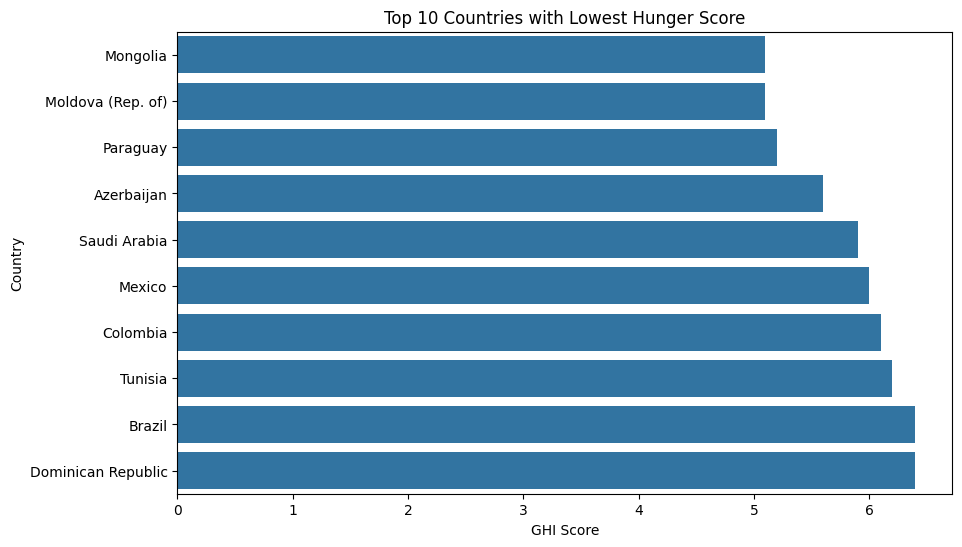

In [ ]:
lowest10 = df.sort_values(by="GHI Score").head(10)

plt.figure(figsize=(10,6))
sns.barplot(x="GHI Score", y="Country", data=lowest10)

plt.title("Top 10 Countries with Lowest Hunger Score")
plt.xlabel("GHI Score")
plt.ylabel("Country")

plt.show()

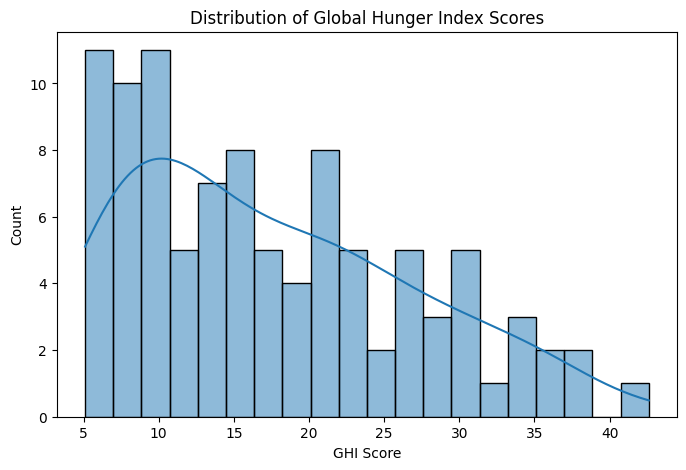

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["GHI Score"], bins=20, kde=True)

plt.title("Distribution of Global Hunger Index Scores")
plt.xlabel("GHI Score")

plt.show()

In [ ]:
# Rename the remaining year columns for consistency and clarity
df.rename(columns={
    "2000\n'98-'02": "GHI_2000",
    "2008\n'06-'10": "GHI_2008",
    "2016\n'14-'18": "GHI_2016",
    "GHI Score": "GHI_2025" # 'GHI Score' was already renamed from '2025\n'20-'24' in K1D084VUUS3V
}, inplace=True)

# Convert all GHI year columns to numeric, coercing errors
year_cols = ['GHI_2000', 'GHI_2008', 'GHI_2016', 'GHI_2025']
for col in year_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows that have NaN values in any of the GHI year columns after conversion
df.dropna(subset=year_cols, inplace=True)

print("DataFrame after renaming year columns and numeric conversion:")
display(df.head())

DataFrame after renaming year columns and numeric conversion:


,Country,GHI_2000,GHI_2008,GHI_2016,GHI_2025,Absolute change since 2016,% change since 2016
0,Afghanistan,49.6,32.7,28.0,29.0,1,3.4
1,Albania,15.3,15.3,6.7,7.0,0.3,4.3
2,Algeria,14.1,10.8,8.0,7.1,-0.9,-12.7
3,Angola,63.8,35.3,25.7,29.7,4,13.5
4,Argentina,6.5,5.2,5.3,6.4,1.1,17.2


In [ ]:
# Melt the DataFrame to long format for easier plotting of trends
df_melted = df.melt(id_vars=['Country'], value_vars=['GHI_2000', 'GHI_2008', 'GHI_2016', 'GHI_2025'],
                      var_name='Year', value_name='GHI Score')

# Extract just the year number from the 'Year' column string, fixing SyntaxWarning with raw string
df_melted['Year'] = df_melted['Year'].str.extract(r'(\d{4})').astype(int)

print("Melted DataFrame head:")
display(df_melted.head())

Melted DataFrame head:


,Country,Year,GHI Score
0,Afghanistan,2000,49.6
1,Albania,2000,15.3
2,Algeria,2000,14.1
3,Angola,2000,63.8
4,Argentina,2000,6.5


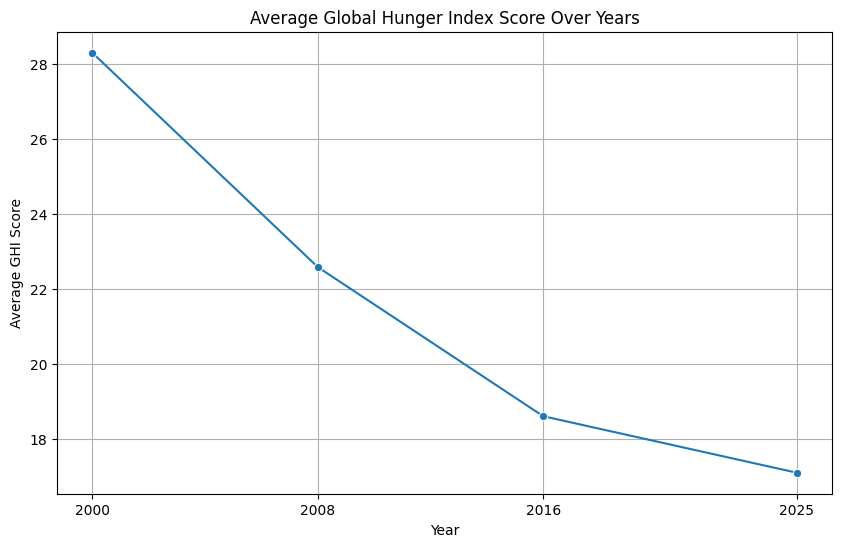

In [ ]:
# Plot the average GHI score over the years
plt.figure(figsize=(10, 6))
sns.lineplot(x='Year', y='GHI Score', data=df_melted, estimator='mean', errorbar=None, marker='o')
plt.title('Average Global Hunger Index Score Over Years')
plt.xlabel('Year')
plt.ylabel('Average GHI Score')
plt.grid(True)
plt.xticks(df_melted['Year'].unique())
plt.show()

/tmp/ipykernel_2759/3975411176.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Absolute_Change_2016_2025', y='Country', data=most_improved, palette='viridis')


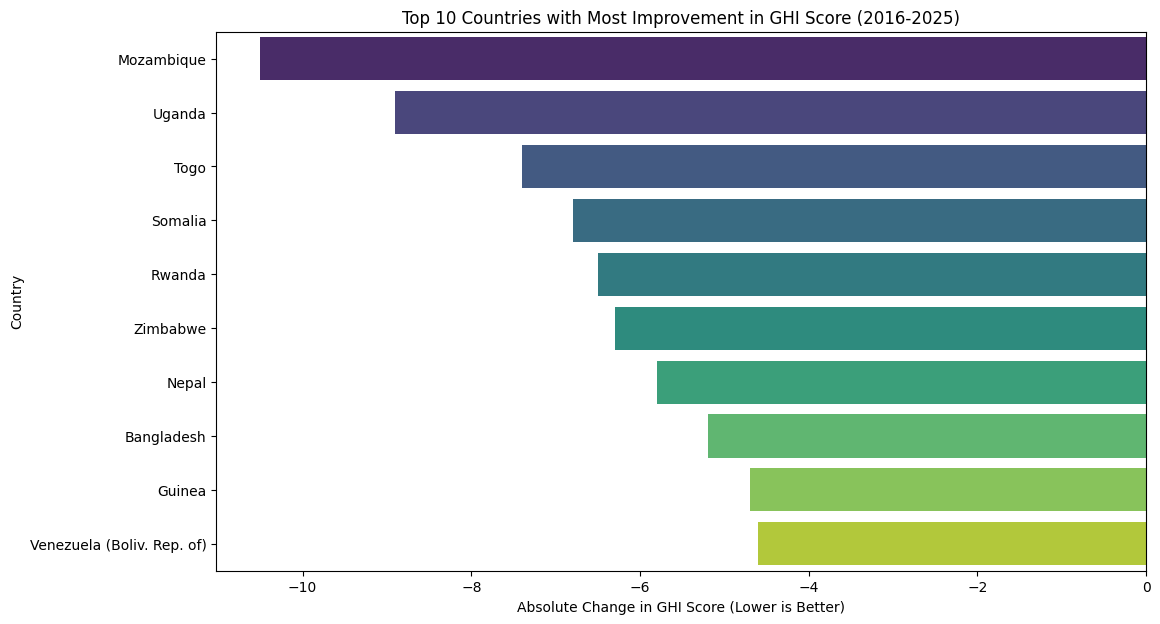

/tmp/ipykernel_2759/3975411176.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Absolute_Change_2016_2025', y='Country', data=most_deteriorated, palette='plasma')


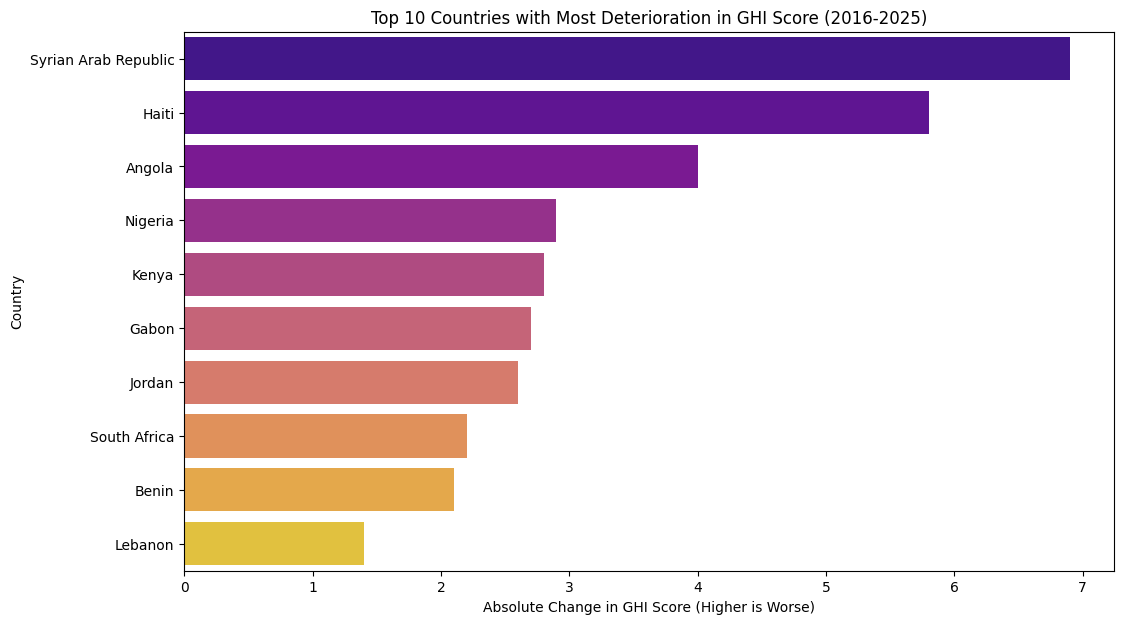

In [ ]:
# Rename change columns for clarity and convert to numeric
df.rename(columns={
    'Absolute change since 2016': 'Absolute_Change_2016_2025',
    '% change since 2016': 'Percentage_Change_2016_2025'
}, inplace=True)

df['Absolute_Change_2016_2025'] = pd.to_numeric(df['Absolute_Change_2016_2025'], errors='coerce')
df['Percentage_Change_2016_2025'] = pd.to_numeric(df['Percentage_Change_2016_2025'], errors='coerce')

# Drop rows where these new columns are NaN after conversion
df.dropna(subset=['Absolute_Change_2016_2025', 'Percentage_Change_2016_2025'], inplace=True)

# Sort by absolute change to see countries with most improvement/deterioration
most_improved = df.sort_values(by='Absolute_Change_2016_2025').head(10)
most_deteriorated = df.sort_values(by='Absolute_Change_2016_2025', ascending=False).head(10)

plt.figure(figsize=(12, 7))
sns.barplot(x='Absolute_Change_2016_2025', y='Country', data=most_improved, palette='viridis')
plt.title('Top 10 Countries with Most Improvement in GHI Score (2016-2025)')
plt.xlabel('Absolute Change in GHI Score (Lower is Better)')
plt.ylabel('Country')
plt.show()

plt.figure(figsize=(12, 7))
sns.barplot(x='Absolute_Change_2016_2025', y='Country', data=most_deteriorated, palette='plasma')
plt.title('Top 10 Countries with Most Deterioration in GHI Score (2016-2025)')
plt.xlabel('Absolute Change in GHI Score (Higher is Worse)')
plt.ylabel('Country')
plt.show()

### World Bank Data Integration and Regression Analysis

To perform regression analysis with World Bank data, we first need to fetch the relevant indicators, merge them with our existing GHI data, and then run the regressions.

In [ ]:
# Install wbgapi if not already installed
!pip install wbgapi

import wbgapi as wb
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf

print("wbgapi and other libraries imported successfully.")

wbgapi and other libraries imported successfully.


#### 1. Map GHI Countries to World Bank ISO Codes

Before fetching World Bank data, we need a reliable way to map the country names in our GHI dataset to their corresponding ISO codes used by the World Bank. This ensures we fetch data for the correct countries.

In [ ]:
# Create a mapping from World Bank country names to ISO3 codes
economy_info_list = wb.economy.list() # Fetch the list of economy dictionaries
economy_info_df = pd.DataFrame(economy_info_list) # Convert it to a DataFrame
country_name_to_iso = {row['value']: row['id'] for idx, row in economy_info_df.iterrows()}

# Add ISO3 codes to df_melted
df_melted['ISO_Code'] = df_melted['Country'].map(country_name_to_iso)

# Drop rows where ISO_Code could not be mapped
df_melted.dropna(subset=['ISO_Code'], inplace=True)

print("df_melted with ISO codes:")
display(df_melted.head())
print(f"Number of countries after mapping: {df_melted['ISO_Code'].nunique()}")

df_melted with ISO codes:


,Country,Year,GHI Score,ISO_Code
0,Afghanistan,2000,49.6,AFG
1,Albania,2000,15.3,ALB
2,Algeria,2000,14.1,DZA
3,Angola,2000,63.8,AGO
4,Argentina,2000,6.5,ARG


Number of countries after mapping: 83


#### 2. Fetch World Bank Indicators

Next, we define the World Bank indicators related to climate and fragility, and then fetch their data for the relevant countries and years using the `wbgapi` library.

In [ ]:
wb_indicators = {
    'AG.LND.FRST.ZS': 'Forest_Area_Pct_Land',
    # Önceki denemelerde API hatası veren göstergeler, referans için yorum satırı olarak bırakıldı:
    # 'EN.ATM.CO2E.PC': 'CO2_Emissions_per_Capita',
    # 'PV.EST': 'Political_Stability_Estimate',

    # Yeni önerilen göstergelerden CO2 emisyonu tekrar hata verdiği için kaldırıldı:
    # 'EN.ATM.CO2E.KT': 'CO2_Emissions_Total_kt', # Alternatif iklim göstergesi
    'SH.STA.SMSS.ZS': 'Sanitation_Services_Pct_Pop'   # Alternatif kırılganlık/çatışma göstergesi (5 Yaş Altı Ölüm Oranı yanlış etiketlenmişti)
}

# Get unique ISO codes from our GHI data to fetch only relevant countries
countries_to_fetch = df_melted['ISO_Code'].unique().tolist()

# Define the range of years (min and max from GHI data, or a broader range)
min_year = df_melted['Year'].min()
max_year = df_melted['Year'].max()
years_to_fetch = [str(y) for y in range(min_year, max_year + 1)] # Convert to list of strings for robustness

all_wb_data = []

for wb_code, new_col_name in wb_indicators.items():
    print(f"Fetching {wb_code} ({new_col_name})...")
    try:
        # Fetch raw data, which is an iterable of dictionaries
        raw_data_generator = wb.data.fetch(
            wb_code,
            economy=countries_to_fetch,
            time=years_to_fetch,
            labels=True # Get country names and indicator names in the dictionaries
        )

        processed_data_list = []
        for item in raw_data_generator:
            # Extract ISO_Code, Year, and the indicator value from the nested dictionary
            if all(k in item and item[k] is not None for k in ['economy', 'time', 'value']) and \
               all(k in item['economy'] and item['economy'][k] is not None for k in ['id']) and \
               all(k in item['time'] and item['time'][k] is not None for k in ['value']):
                try:
                    iso_code = item['economy']['id']
                    year = int(item['time']['value']) # 'time'['value'] is like '2000'
                    indicator_value = item['value']

                    processed_data_list.append({
                        'ISO_Code': iso_code,
                        'Year': year,
                        new_col_name: indicator_value
                    })
                except (ValueError, TypeError) as e:
                    print(f"Skipping malformed data point for {wb_code}: {item}. Error: {e}")
            else:
                # Removed: print(f"Skipping incomplete data point for {wb_code}: {item}")
                pass # Suppress the output for incomplete data points

        df_temp = pd.DataFrame(processed_data_list)

        if not df_temp.empty:
            all_wb_data.append(df_temp)
        else:
            print(f"No valid data found for {wb_code}.")

    except Exception as e:
        print(f"Error fetching {wb_code}: {e}")

if all_wb_data:
    # Merge all World Bank indicators into a single DataFrame
    # Start with the first DataFrame and iteratively merge
    df_wb_merged = all_wb_data[0]
    for i in range(1, len(all_wb_data)):
        df_wb_merged = pd.merge(df_wb_merged, all_wb_data[i], on=['ISO_Code', 'Year'], how='outer')

    print("\nMerged World Bank data (head):")
    display(df_wb_merged.head())
else:
    print("No World Bank data was successfully fetched.")
    df_wb_merged = pd.DataFrame()

Fetching AG.LND.FRST.ZS (Forest_Area_Pct_Land)...
Fetching SH.STA.SMSS.ZS (Sanitation_Services_Pct_Pop)...

Merged World Bank data (head):


,ISO_Code,Year,Forest_Area_Pct_Land,Sanitation_Services_Pct_Pop
0,AFG,2000,1.852782,10.132092
1,AFG,2001,1.852782,10.131490
2,AFG,2002,1.852782,10.853967
3,AFG,2003,1.852782,11.576335
4,AFG,2004,1.852782,12.298131


#### 3. Merge GHI Data with World Bank Data

Now we combine our `df_melted` (GHI scores) with the `df_wb_merged` (World Bank indicators) based on `ISO_Code` and `Year`. This will create a comprehensive dataset for our regression analysis.

In [ ]:
if not df_wb_merged.empty:
    df_final = pd.merge(df_melted, df_wb_merged, on=['ISO_Code', 'Year'], how='inner')
    print("Final Merged DataFrame (head):")
    display(df_final.head())
    print(f"Final DataFrame shape: {df_final.shape}")
else:
    print("Cannot perform merge as no World Bank data was fetched.")
    df_final = pd.DataFrame()

# Let's inspect data types and missing values in the final DataFrame
print("\nInfo on final merged DataFrame:")
df_final.info()
print("\nMissing values in final merged DataFrame:")
display(df_final.isnull().sum())

Final Merged DataFrame (head):


,Country,Year,GHI Score,ISO_Code,Forest_Area_Pct_Land,Sanitation_Services_Pct_Pop
0,Afghanistan,2000,49.6,AFG,1.852782,10.132092
1,Albania,2000,15.3,ALB,28.076642,22.879987
2,Algeria,2000,14.1,DZA,0.662961,58.852871
3,Angola,2000,63.8,AGO,62.331443,NaN
4,Argentina,2000,6.5,ARG,12.196486,48.131364


Final DataFrame shape: (249, 6)

Info on final merged DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Country                      249 non-null    object 
 1   Year                         249 non-null    int64  
 2   GHI Score                    249 non-null    float64
 3   ISO_Code                     249 non-null    object 
 4   Forest_Area_Pct_Land         249 non-null    float64
 5   Sanitation_Services_Pct_Pop  173 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 11.8+ KB

Missing values in final merged DataFrame:


,0
Country,0
Year,0
GHI Score,0
ISO_Code,0
Forest_Area_Pct_Land,0
Sanitation_Services_Pct_Pop,76


#### 4. Regression Analysis (Superseded by ML Modeling Section)

*Note: This section contains an initial regression analysis that is now superseded by the more comprehensive machine learning modeling performed in the subsequent sections. We are keeping the code commented out to avoid redundancy.*

In [ ]:
# This section is commented out as its functionality is now covered by the dedicated ML modeling section.
# if not df_final.empty:
#     # Drop rows with any NaN values in the columns used for regression
#     regression_df = df_final.dropna(subset=['GHI Score'] + list(wb_indicators.values()))

#     if not regression_df.empty:
#         print("\n--- Regression Analysis ---\n")
#         for indicator_col in wb_indicators.values():
#             print(f"\nRegression for GHI Score vs. {indicator_col}:")
#             try:
#                 # Fit the OLS model
#                 model = smf.ols(f"Q('GHI Score') ~ Q('{indicator_col}')", data=regression_df).fit()
#                 # Print the summary of the regression
#                 print(model.summary())
#             except ValueError as e:
#                 print(f"Could not perform regression for {indicator_col}: {e}")
#     else:
#         print("Not enough non-null data to perform regression after dropping NaNs.")
# else:
#     print("Cannot perform regression analysis as the final DataFrame is empty.")

### 1. Model Selection & Justification

Our problem involves predicting a continuous numerical value, the Global Hunger Index (GHI) Score, based on various socioeconomic and environmental indicators. This is a classic **regression problem**.

For the initial modeling phase, we will choose a simple yet powerful and interpretable model:

*   **Linear Regression:**
    *   **Rationale:** Linear Regression is chosen as a baseline model due to its simplicity, interpretability, and effectiveness in identifying linear relationships between features and the target variable. It helps us understand the direct impact (positive or negative) of each feature on the GHI Score.
    *   **SDG Alignment:** By modeling the GHI Score, we aim to understand which indicators significantly influence hunger levels. This directly supports **SDG 2: Zero Hunger** by providing insights into potential drivers that can be targeted for intervention. If, for example, a specific indicator has a strong linear relationship with GHI, it highlights an area where policy or development efforts could make a measurable difference in reducing hunger.

### 2. Data Preparation for Modeling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

print("Required libraries for modeling imported successfully.")

Required libraries for modeling imported successfully.


In [ ]:
# Define features (X) and target (y)
# We use the regression_df which already has NaNs handled for the selected indicators.

X = regression_df[['Forest_Area_Pct_Land', 'Sanitation_Services_Pct_Pop']]
y = regression_df['GHI Score']

# Split the dataset into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Original features shape: {X.shape}")
print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Original features shape: (173, 2)
Training features shape: (138, 2)
Testing features shape: (35, 2)
Training target shape: (138,)
Testing target shape: (35,)


In [ ]:
# Normalize/standardize features
# Initialize StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features have been scaled.")
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())

Features have been scaled.


,Forest_Area_Pct_Land,Sanitation_Services_Pct_Pop
0,0.510398,0.197604
1,1.796532,-0.733457
2,1.247086,2.376118
3,-1.087142,0.819630
4,1.043790,-0.692605


### 3. Model Training & Evaluation

In [ ]:
# Initialize and train the Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Linear Regression model trained successfully.")
print(f"Model Coefficients: {model.coef_}")
print(f"Model Intercept: {model.intercept_}")

Linear Regression model trained successfully.
Model Coefficients: [-2.00852497 -7.45570278]
Model Intercept: 21.91594202898551


In [ ]:
# Make predictions on the training and test sets
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Evaluate the model on the training set
mse_train = mean_squared_error(y_train, y_train_pred)
r2_train = r2_score(y_train, y_train_pred)

print("\n--- Training Set Evaluation ---")
print(f"Mean Squared Error (Train): {mse_train:.2f}")
print(f"R-squared (Train): {r2_train:.2f}")

# Evaluate the model on the test set
mse_test = mean_squared_error(y_test, y_test_pred)
r2_test = r2_score(y_test, y_test_pred)

print("\n--- Test Set Evaluation ---")
print(f"Mean Squared Error (Test): {mse_test:.2f}")
print(f"R-squared (Test): {r2_test:.2f}")


--- Training Set Evaluation ---
Mean Squared Error (Train): 88.95
R-squared (Train): 0.40

--- Test Set Evaluation ---
Mean Squared Error (Test): 85.17
R-squared (Test): 0.48


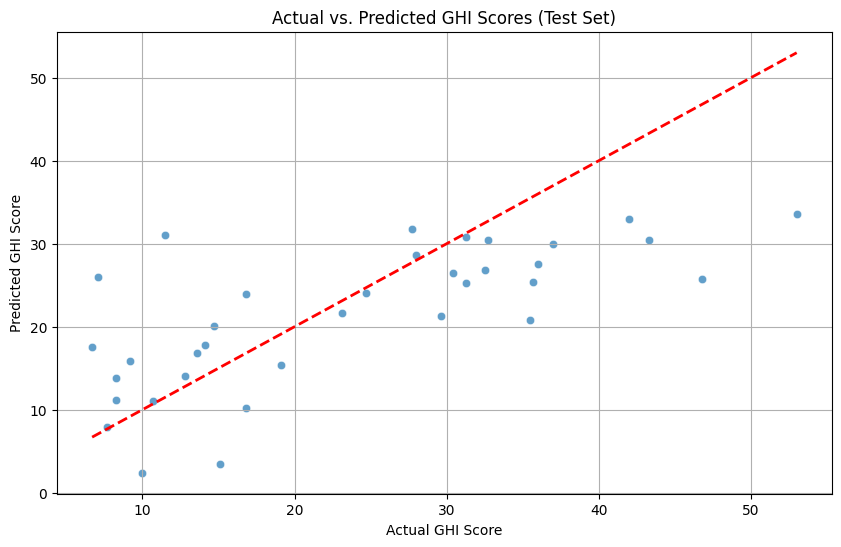

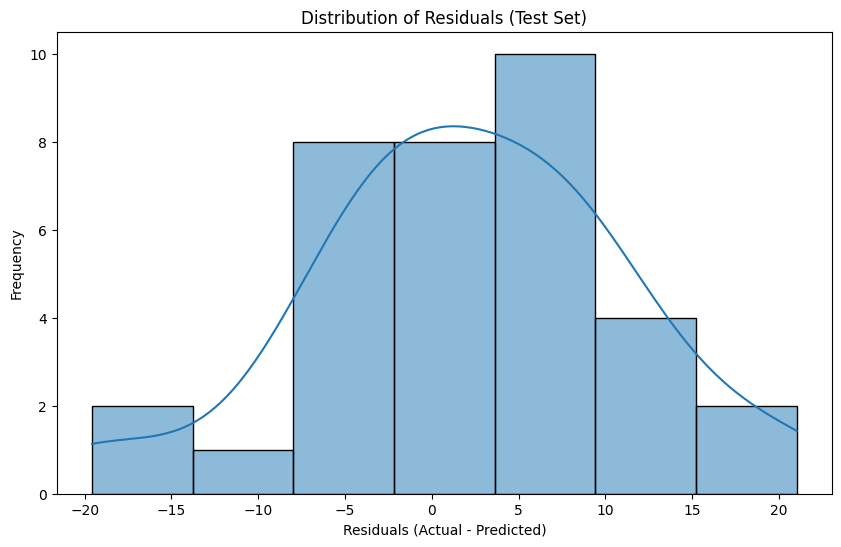

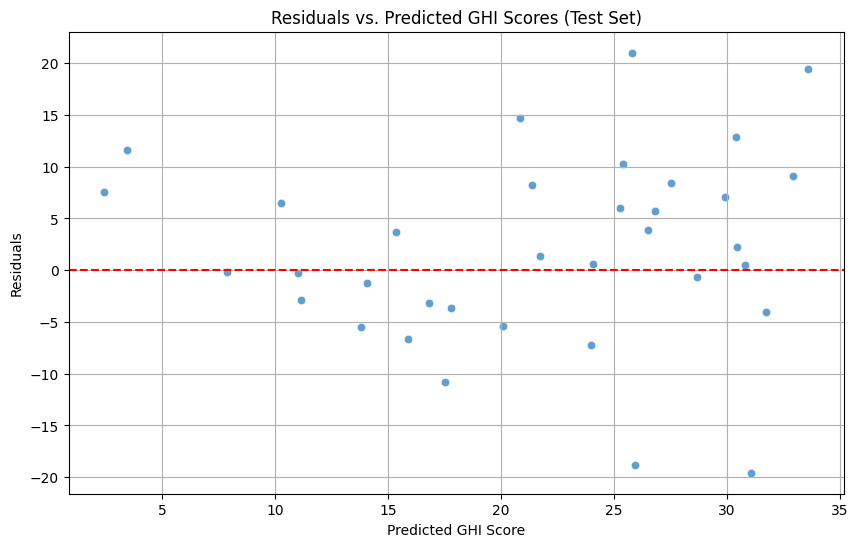

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize predictions vs. actuals for the test set
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # y=x line
plt.title('Actual vs. Predicted GHI Scores (Test Set)')
plt.xlabel('Actual GHI Score')
plt.ylabel('Predicted GHI Score')
plt.grid(True)
plt.show()

# Visualize residuals for the test set
residuals = y_test - y_test_pred
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Distribution of Residuals (Test Set)')
plt.xlabel('Residuals (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.7)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Predicted GHI Scores (Test Set)')
plt.xlabel('Predicted GHI Score')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

### 4. Interpretation of Results

In [ ]:
print("Model Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"Model Intercept: {model.intercept_:.4f}")

print("\nInterpretation of Coefficients:")
print("- A positive coefficient indicates that as the feature value increases, the GHI Score (hunger) is predicted to increase.")
print("- A negative coefficient indicates that as the feature value increases, the GHI Score (hunger) is predicted to decrease.")
print("\nFor example, if the coefficient for 'Sanitation_Services_Pct_Pop' is negative, it suggests that better sanitation (higher percentage) is associated with lower GHI Scores (less hunger).")
print("\nConsider the R-squared values for both training and test sets to understand the model's explanatory power and generalization ability.")

Model Coefficients:
  Forest_Area_Pct_Land: -2.0085
  Sanitation_Services_Pct_Pop: -7.4557
Model Intercept: 21.9159

Interpretation of Coefficients:
- A positive coefficient indicates that as the feature value increases, the GHI Score (hunger) is predicted to increase.
- A negative coefficient indicates that as the feature value increases, the GHI Score (hunger) is predicted to decrease.

For example, if the coefficient for 'Sanitation_Services_Pct_Pop' is negative, it suggests that better sanitation (higher percentage) is associated with lower GHI Scores (less hunger).

Consider the R-squared values for both training and test sets to understand the model's explanatory power and generalization ability.
